<a href="https://www.kaggle.com/code/sonawanelalitsunil/brain-tumor-mri-dataset-ml-76-74?scriptVersionId=228208231" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-tumor-dataset/brain_tumor_dataset.csv


## Title: Brain Tumor MRI Dataset for Classification and Segmentation

#### Description: A medical imaging dataset containing MRI scans labeled for the presence and type of brain tumors. Suitable for classification, segmentation, and deep learning applications in medical AI.

## import dataset

In [2]:
df = pd.read_csv('/kaggle/input/brain-tumor-dataset/brain_tumor_dataset.csv')

In [3]:
df.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


In [4]:
df.tail()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
19995,19996,21,Male,Malignant,9.612013,Parietal,Medulloblastoma,III,Seizures,Nausea,Vision Issues,No,No,Yes,58.229662,0.353806,No,Negative,Yes
19996,19997,32,Female,Benign,1.543560,Temporal,Meningioma,III,Headache,Headache,Vision Issues,Yes,Yes,No,77.706856,2.341074,No,Positive,No
19997,19998,57,Female,Benign,3.618634,Temporal,Medulloblastoma,I,Seizures,Vision Issues,Nausea,No,No,Yes,89.543803,2.332881,No,Positive,Yes
19998,19999,68,Male,Malignant,8.519086,Parietal,Glioblastoma,III,Seizures,Headache,Vision Issues,Yes,Yes,Yes,83.306781,2.387202,No,Positive,No
19999,20000,61,Male,Benign,9.716768,Temporal,Medulloblastoma,I,Vision Issues,Seizures,Nausea,No,No,No,47.433468,2.464077,Yes,Negative,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

In [6]:
df.dtypes

Patient_ID               int64
Age                      int64
Gender                  object
Tumor_Type              object
Tumor_Size             float64
Location                object
Histology               object
Stage                   object
Symptom_1               object
Symptom_2               object
Symptom_3               object
Radiation_Treatment     object
Surgery_Performed       object
Chemotherapy            object
Survival_Rate          float64
Tumor_Growth_Rate      float64
Family_History          object
MRI_Result              object
Follow_Up_Required      object
dtype: object

In [7]:
df.isnull().sum()

Patient_ID             0
Age                    0
Gender                 0
Tumor_Type             0
Tumor_Size             0
Location               0
Histology              0
Stage                  0
Symptom_1              0
Symptom_2              0
Symptom_3              0
Radiation_Treatment    0
Surgery_Performed      0
Chemotherapy           0
Survival_Rate          0
Tumor_Growth_Rate      0
Family_History         0
MRI_Result             0
Follow_Up_Required     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(20000, 19)

In [10]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Tumor_Type', 'Tumor_Size', 'Location',
       'Histology', 'Stage', 'Symptom_1', 'Symptom_2', 'Symptom_3',
       'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy',
       'Survival_Rate', 'Tumor_Growth_Rate', 'Family_History', 'MRI_Result',
       'Follow_Up_Required'],
      dtype='object')

## Data visualizations

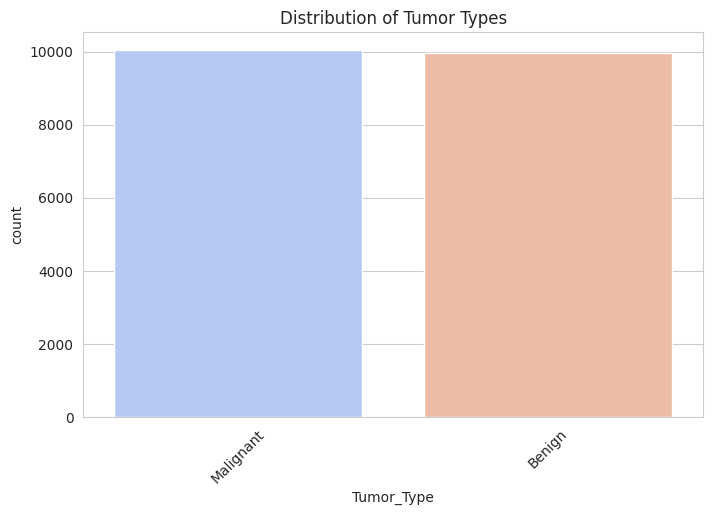

In [11]:
# Set visual style
sns.set_style("whitegrid")

# 1. Tumor Type Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Tumor_Type', palette='coolwarm', order=df['Tumor_Type'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of Tumor Types')
plt.show()

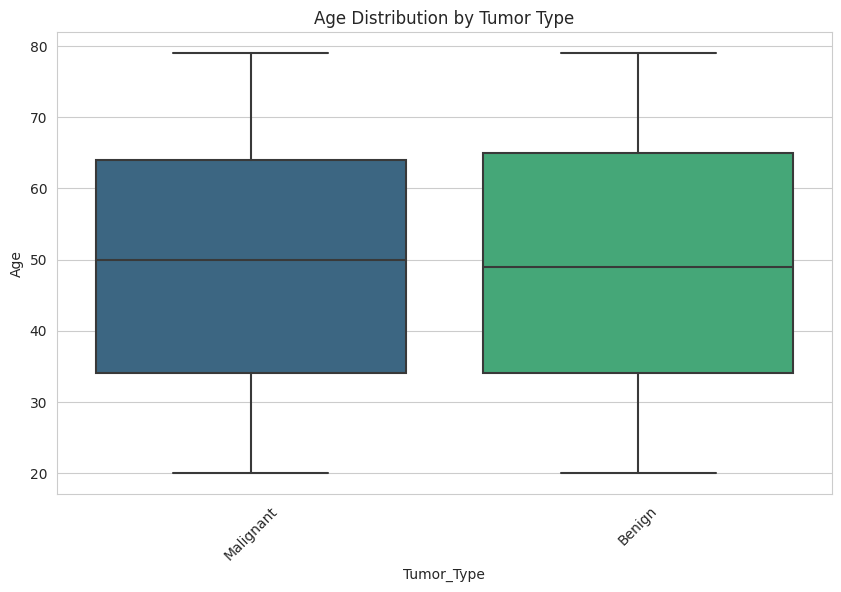

In [12]:
# 2. Age Distribution by Tumor Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tumor_Type', y='Age', palette='viridis')
plt.xticks(rotation=45)
plt.title('Age Distribution by Tumor Type')
plt.show()

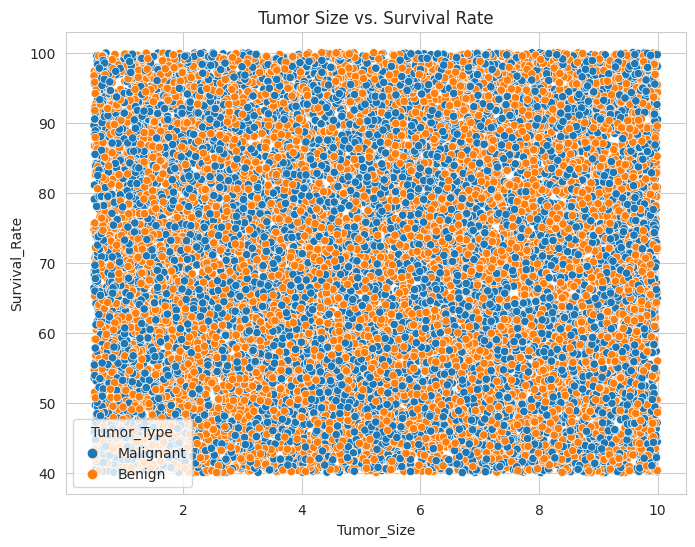

In [13]:
# 3. Tumor Size vs. Survival Rate
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Tumor_Size', y='Survival_Rate', hue='Tumor_Type', palette='tab10')
plt.title('Tumor Size vs. Survival Rate')
plt.show()

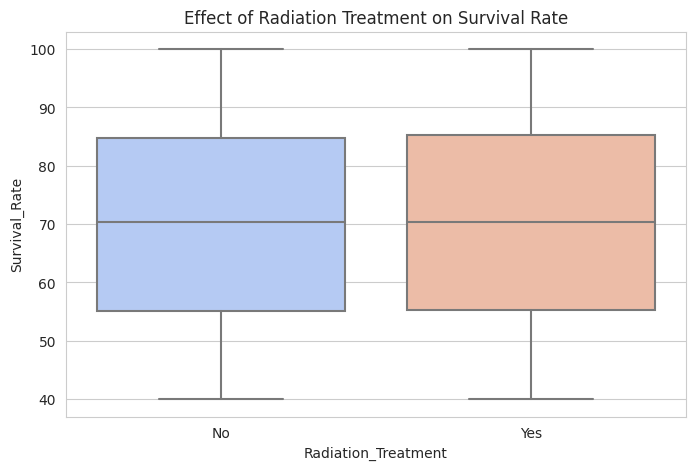

In [14]:
# 4. Impact of Radiation Treatment on Survival Rate
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Radiation_Treatment', y='Survival_Rate', palette='coolwarm')
plt.title('Effect of Radiation Treatment on Survival Rate')
plt.show()

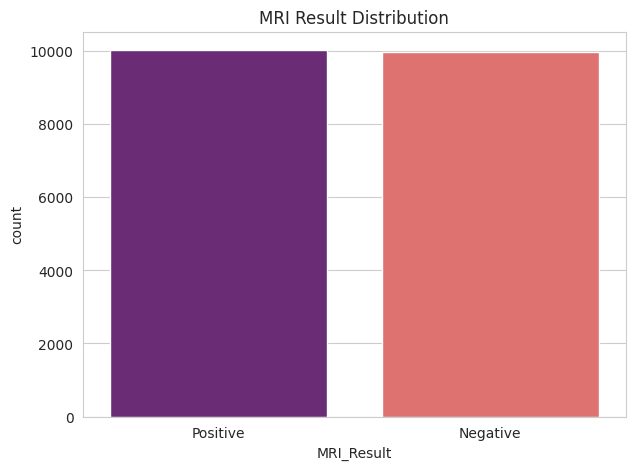

In [15]:
# 5. MRI Result Distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='MRI_Result', palette='magma')
plt.title('MRI Result Distribution')
plt.show()

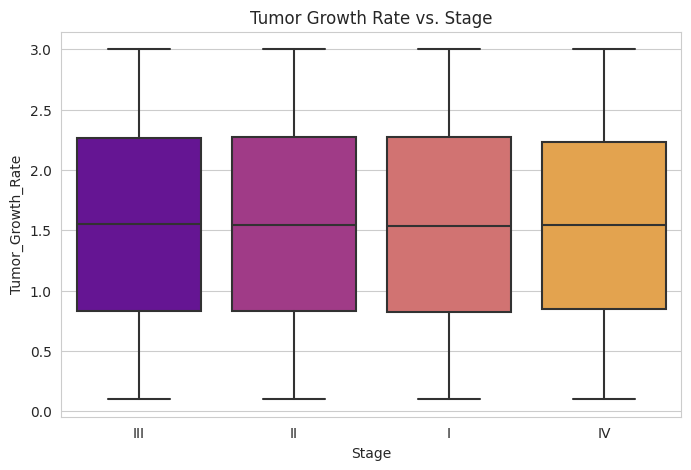

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Stage', y='Tumor_Growth_Rate', palette='plasma')
plt.title('Tumor Growth Rate vs. Stage')
plt.show()

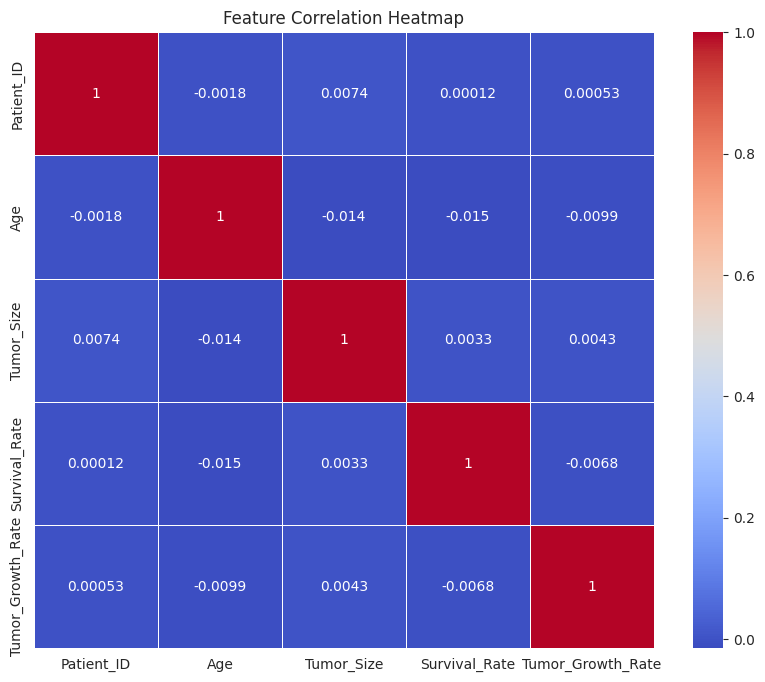

In [17]:
# 7. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [19]:
# Encode categorical variables
label_encoders = {}
categorical_columns = ['Gender', 'Tumor_Type', 'Location', 'Histology', 'Stage', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy', 'Family_History', 'MRI_Result', 'Follow_Up_Required']

In [20]:
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [21]:
# Train-test split
X = df.drop(columns=['Patient_ID', 'Survival_Rate'])  # Exclude ID and target variable
y = df['Survival_Rate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor()
}

In [23]:
# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    accuracy = 100 - mape
    
    print(f"{name} Performance:")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    print(f"Accuracy: {accuracy:.2f}%\n")

Linear Regression Performance:
Mean Absolute Error: 14.8062
Mean Squared Error: 295.0935
R^2 Score: -0.0003
Accuracy: 76.74%

Decision Tree Performance:
Mean Absolute Error: 20.1671
Mean Squared Error: 608.7958
R^2 Score: -1.0637
Accuracy: 68.81%

Random Forest Performance:
Mean Absolute Error: 14.9049
Mean Squared Error: 302.8083
R^2 Score: -0.0265
Accuracy: 76.60%

Support Vector Regressor Performance:
Mean Absolute Error: 14.8028
Mean Squared Error: 294.9443
R^2 Score: 0.0002
Accuracy: 76.73%

K-Nearest Neighbors Performance:
Mean Absolute Error: 15.7226
Mean Squared Error: 348.7810
R^2 Score: -0.1823
Accuracy: 75.41%



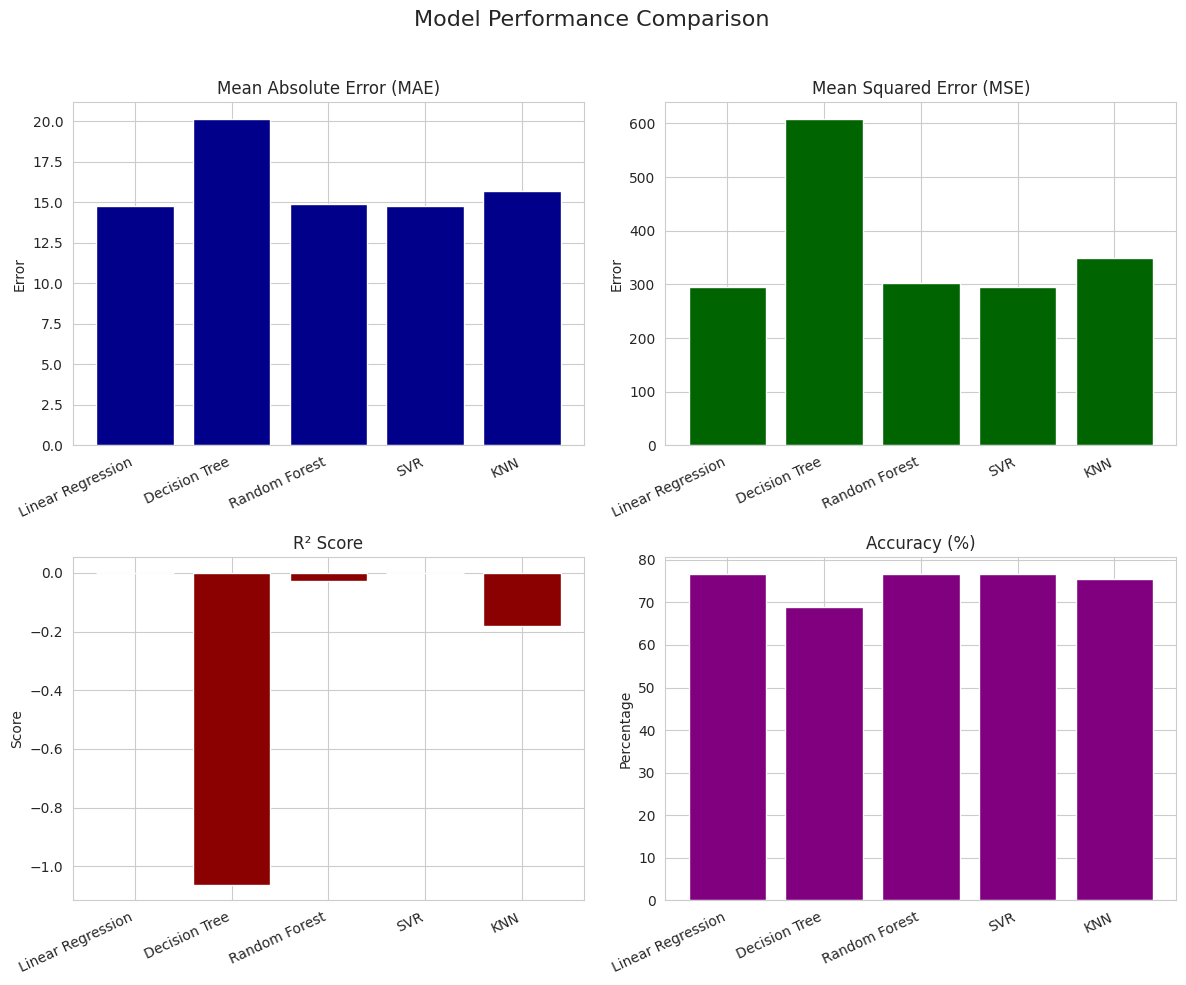

In [24]:
# Model names
models = ["Linear Regression", "Decision Tree", "Random Forest", "SVR", "KNN"]

# Performance metrics
mae = [14.8062, 20.1671, 14.9049, 14.8028, 15.7226]
mse = [295.0935, 608.7958, 302.8083, 294.9443, 348.7810]
r2 = [-0.0003, -1.0637, -0.0265, 0.0002, -0.1823]
accuracy = [76.74, 68.81, 76.60, 76.73, 75.41]

# Creating subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Model Performance Comparison", fontsize=16)

# MAE Plot
axes[0, 0].bar(models, mae, color="darkblue")
axes[0, 0].set_title("Mean Absolute Error (MAE)")
axes[0, 0].set_ylabel("Error")

# MSE Plot
axes[0, 1].bar(models, mse, color="darkgreen")
axes[0, 1].set_title("Mean Squared Error (MSE)")
axes[0, 1].set_ylabel("Error")

# R^2 Score Plot
axes[1, 0].bar(models, r2, color="darkred")
axes[1, 0].set_title("R² Score")
axes[1, 0].set_ylabel("Score")

# Accuracy Plot
axes[1, 1].bar(models, accuracy, color="purple")
axes[1, 1].set_title("Accuracy (%)")
axes[1, 1].set_ylabel("Percentage")

# Rotate x-axis labels for better readability
for ax in axes.flat:
    ax.set_xticklabels(models, rotation=25, ha="right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Thank you!!!!.....pls upvote!!!